# Feature Engineering Notebook

## Import Libraries and Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/cleaned_data.csv')

In [2]:
df.head()

,Unnamed: 0,meal,create_date,meal_type_id,dou_code,resto_name,count,breakfast,launch,dinner
0,0,بطاطا كوشة,2023-12-19,3,11,ANON_b520e3d2e6d0,172,0,172,0
1,1,شوربة شعرية,2023-12-19,3,11,ANON_b520e3d2e6d0,172,0,172,0
2,2,لحم طازج,2023-12-19,3,11,ANON_b520e3d2e6d0,172,0,172,0
3,3,عصير الفواكه,2023-12-19,3,11,ANON_b520e3d2e6d0,172,0,172,0
4,4,خبز,2023-12-19,3,11,ANON_b520e3d2e6d0,172,0,172,0


## Feature Creation

In [3]:
# rename 'create_date' column to 'date'
df.rename(columns={'create_date': 'date'}, inplace=True)

In [4]:
# create new feature 'day_of_week' from 'date' column
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.day_name()

In [5]:
# create new feature 'is_weekend' from 'day_of_week' column
df['is_weekend'] = df['day_of_week'].isin(['Friday', 'Saturday']).astype(int)

In [6]:
# create new feature 'meal_type' from 'meal_type_id' column
meal_type_mapping = {1: 'breakfast', 2: 'lunch', 3: 'dinner'}
df['meal_type'] = df['meal_type_id'].map(meal_type_mapping)

In [78]:
holiday_ranges = [
    ('2024-03-21', '2024-04-06'),  # spring
    ('2024-12-19', '2025-01-05')   # winter
]

holiday_dates = pd.DatetimeIndex([])

for start, end in holiday_ranges:
    holiday_dates = holiday_dates.union(
        pd.date_range(start, end)
    )

df['is_holiday'] = df['date'].isin(holiday_dates).astype(int)

In [7]:
# group meal names of same id and date and meal type by concatenating them with a comma and add column with number of meal items
df['meal_items'] = df.groupby(['dou_code', 'date', 'meal_type'])['meal'].transform(lambda x: ', '.join(x))
df['num_meal_items'] = df.groupby(['dou_code', 'date', 'meal_type'])['meal'].transform('count')

In [8]:
# drop 'meal_type_id' column as we have created 'meal_type' feature from it
df.drop(columns=['meal_type_id'], inplace=True)

In [10]:
# drop 'meal' column as it has too many unique values and not relevant for our analysis
df.drop(columns=['meal'], inplace=True)

In [12]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [13]:
df.head()

,date,dou_code,resto_name,count,breakfast,launch,dinner,day_of_week,is_weekend,meal_type,meal_items,num_meal_items
0,2023-12-19,11,ANON_b520e3d2e6d0,172,0,172,0,Tuesday,0,dinner,"بطاطا كوشة, شوربة شعرية, لحم طازج, عصير الفواك...",5
1,2023-12-19,11,ANON_b520e3d2e6d0,172,0,172,0,Tuesday,0,dinner,"بطاطا كوشة, شوربة شعرية, لحم طازج, عصير الفواك...",5
2,2023-12-19,11,ANON_b520e3d2e6d0,172,0,172,0,Tuesday,0,dinner,"بطاطا كوشة, شوربة شعرية, لحم طازج, عصير الفواك...",5
3,2023-12-19,11,ANON_b520e3d2e6d0,172,0,172,0,Tuesday,0,dinner,"بطاطا كوشة, شوربة شعرية, لحم طازج, عصير الفواك...",5
4,2023-12-19,11,ANON_b520e3d2e6d0,172,0,172,0,Tuesday,0,dinner,"بطاطا كوشة, شوربة شعرية, لحم طازج, عصير الفواك...",5


In [15]:
# add 3 new features for each canteen_id which are the average count of meals served for each meal type (breakfast, lunch, dinner) across all dates
meal_type_counts = df.groupby(['resto_name', 'meal_type'])['num_meal_items'].mean().unstack(fill_value=0)
meal_type_counts.columns = [f'avg_{col}_count' for col in meal_type_counts.columns]
df = df.merge(meal_type_counts, on='resto_name', how='left')

In [16]:
# save a json file with the mapping of resto_name to average meal counts for each meal type
resto_meal_counts = meal_type_counts.reset_index().to_dict(orient='records')
import json
with open('../data/processed/resto_meal_counts.json', 'w') as f:
    json.dump(resto_meal_counts, f, indent=4)


In [17]:
# drop 'resto_name' column as it has too many unique values and not relevant for our analysis
df.drop(columns=['resto_name'], inplace=True)

In [19]:
# drop duplicate rows if any
df.drop_duplicates(inplace=True)

In [20]:
df.shape

(669683, 14)

In [21]:
df.head()

,date,dou_code,count,breakfast,launch,dinner,day_of_week,is_weekend,meal_type,meal_items,num_meal_items,avg_breakfast_count,avg_dinner_count,avg_lunch_count
0,2023-12-19,11,172,0,172,0,Tuesday,0,dinner,"بطاطا كوشة, شوربة شعرية, لحم طازج, عصير الفواك...",5,18.700541,33.621392,33.540023
5,2023-12-19,11,172,0,172,0,Tuesday,0,lunch,"مرق بالحمص, سلطة خضراء, سمك تونا, فاكهة موسمية...",5,18.700541,33.621392,33.540023
10,2023-12-19,11,172,0,172,0,Tuesday,0,breakfast,"حليب بالقهوة, مـــــــادلين",2,18.700541,33.621392,33.540023
12,2023-12-20,11,124,0,124,0,Wednesday,0,dinner,"مرق فاصولياء بيضاء, سلطة مـــــاسيدوان, جبن , ...",5,18.700541,33.621392,33.540023
17,2023-12-20,11,124,0,124,0,Wednesday,0,lunch,"مرق بالمعكرونة, سلطة أردوف, لحم دجاج, فاكهة مو...",5,18.700541,33.621392,33.540023


## Encoding Categorical Variables

In [93]:
# encode 'day_of_week' column using one-hot encoding
df = pd.get_dummies(df, columns=['day_of_week'], drop_first=True)

In [94]:
# encode using TF_IDF vectorizer for 'meal_items' column
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=100)
tfidf_matrix = tfidf.fit_transform(df['meal_items'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
df = pd.concat([df, tfidf_df], axis=1)

In [95]:
df.drop(columns=['meal_items'], inplace=True)

In [96]:
df.head()

,date,canteen_id,count,breakfast,launch,dinner,is_weekend,meal_type,is_holiday,num_meal_items,...,معدني,معطر,مفروم,مقلية,موز,موسمية,هلاليات,ياؤورت,ياغورت,ياوورت
0,2023-11-29,4.0,15.0,0.0,15.0,0.0,0.0,breakfast,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2023-11-29,4.0,15.0,0.0,15.0,0.0,0.0,lunch,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2023-11-29,4.0,15.0,0.0,15.0,0.0,0.0,dinner,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,2023-11-30,4.0,4.0,0.0,4.0,0.0,0.0,breakfast,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,2023-11-30,4.0,4.0,0.0,4.0,0.0,0.0,lunch,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [97]:
# split data to 3 dataframes for each meal type
breakfast_df = df[df['meal_type'] == 'breakfast'].copy()
lunch_df = df[df['meal_type'] == 'lunch'].copy()
dinner_df = df[df['meal_type'] == 'dinner'].copy()

In [98]:
# drop 'meal_type' column from each dataframe as it is no longer needed
breakfast_df.drop(columns=['meal_type'], inplace=True)
lunch_df.drop(columns=['meal_type'], inplace=True)
dinner_df.drop(columns=['meal_type'], inplace=True)

In [99]:
# drop other average meal count columns from each dataframe as they are not relevant for that meal type
breakfast_df.drop(columns=['avg_lunch_count', 'avg_dinner_count'], inplace=True)
lunch_df.drop(columns=['avg_breakfast_count', 'avg_dinner_count'], inplace=True)
dinner_df.drop(columns=['avg_breakfast_count', 'avg_lunch_count'], inplace=True)

In [100]:
# drop count of each meal type ['dinner', 'launch', 'breakfast'] from each dataframe as it is not relevant for that meal type
breakfast_df.drop(columns=['dinner','launch'], inplace=True)
lunch_df.drop(columns=['dinner','breakfast'], inplace=True)
dinner_df.drop(columns=['launch','breakfast'], inplace=True)

In [104]:
# drop 'count' column from each dataframe as it is not relevant for our analysis
breakfast_df.drop(columns=['count'], inplace=True)

In [105]:
breakfast_df.head()

,date,canteen_id,breakfast,is_weekend,is_holiday,avg_breakfast_count,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,...,معدني,معطر,مفروم,مقلية,موز,موسمية,هلاليات,ياؤورت,ياغورت,ياوورت
0,2023-11-29,4.0,0.0,0.0,0.0,2.0,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
12,2023-11-30,4.0,0.0,0.0,0.0,2.0,False,False,False,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
24,2023-12-03,4.0,0.0,1.0,0.0,2.0,False,False,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.638123,0.0,0.0,0.0
35,2023-12-04,4.0,0.0,0.0,0.0,2.0,True,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
47,2023-12-05,4.0,0.0,0.0,0.0,2.0,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


## Scaling and Normalization

In [106]:
# normalize the average meal count features in each dataframe using Min-Max scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
breakfast_df[['avg_breakfast_count']] = scaler.fit_transform(breakfast_df[['avg_breakfast_count']])
lunch_df[['avg_lunch_count']] = scaler.fit_transform(lunch_df[['avg_lunch_count']])
dinner_df[['avg_dinner_count']] = scaler.fit_transform(dinner_df[['avg_dinner_count']])

## Base line model

In [115]:
dinner_df[dinner_df['canteen_id'] == 26]

,date,canteen_id,count,dinner,is_weekend,is_holiday,num_meal_items,avg_dinner_count,day_of_week_Monday,day_of_week_Saturday,...,معدني,معطر,مفروم,مقلية,موز,موسمية,هلاليات,ياؤورت,ياغورت,ياوورت
100600,2024-01-15,26.0,2.0,0.0,0.0,0.0,6.0,0.577277,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100614,2024-01-17,26.0,2.0,0.0,0.0,0.0,5.0,0.577277,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100627,2024-01-18,26.0,8.0,0.0,0.0,0.0,5.0,0.577277,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100641,2024-01-21,26.0,14.0,0.0,1.0,0.0,5.0,0.577277,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100654,2024-01-22,26.0,90.0,0.0,0.0,0.0,6.0,0.577277,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107415,2026-04-05,26.0,1412.0,738.0,1.0,0.0,5.0,0.577277,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107429,2026-04-06,26.0,1568.0,771.0,0.0,0.0,5.0,0.577277,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107443,2026-04-07,26.0,887.0,389.0,0.0,0.0,5.0,0.577277,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107457,2026-04-08,26.0,1263.0,576.0,0.0,0.0,5.0,0.577277,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
# unique canteen ids in dinner_df
dinner_df['canteen_id'].unique()

array([ 4.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16., 17., 18.,
       19., 20., 21., 22., 23., 24., 25., 26., 27., 28., 29., 30., 31.,
       32., 33., 34., 35., 36., 37., 38., 39., 40., 41., 42., 43., 44.,
       45., 46., 47., 48., 49., 50., 51., 52., 53., 54., 55., 56., 57.,
       58., 59., 60., 61., 62., 63., 64., 65., 66.])

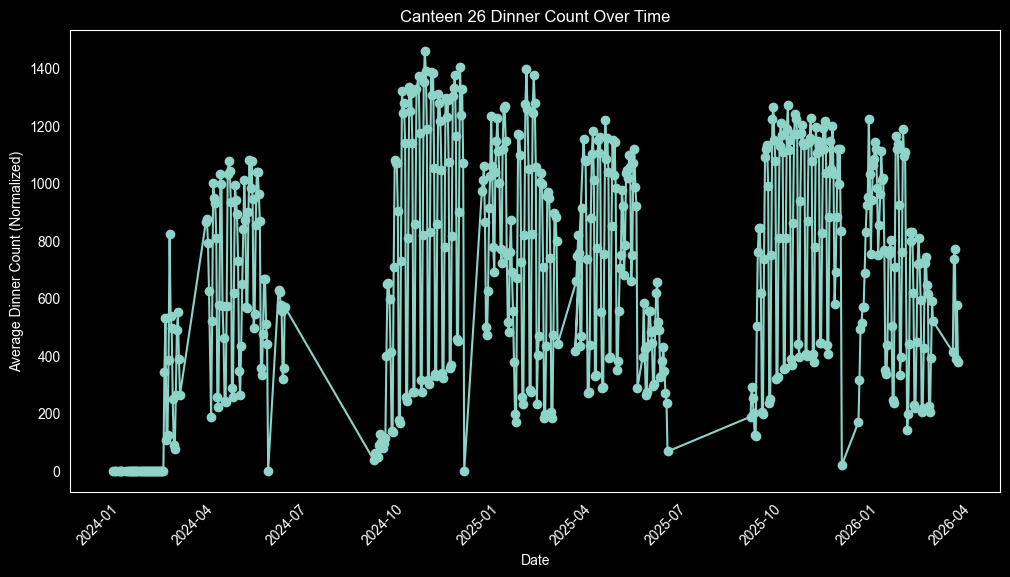

In [116]:
canteen_id =26
# plot dinner count for canteen_id 4 across all dates
import matplotlib.pyplot as plt
canteen_dinner_df = dinner_df[dinner_df['canteen_id'] == canteen_id]
plt.figure(figsize=(12, 6))
plt.plot(canteen_dinner_df['date'], canteen_dinner_df['dinner'], marker='o')
plt.title(f'Canteen {canteen_id} Dinner Count Over Time')
plt.xlabel('Date')
plt.ylabel('Average Dinner Count (Normalized)')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [ ]:
# train a simple linear regression model to predict dinner count for canteen_id 26 using date as the only feature
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = canteen_dinner_df.drop(columns=['canteen_id','date,'])
y = canteen_dinner_df['dinner']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Export Final Dataset for Modeling

In [103]:
# df.to_csv('../data/processed/final_features.csv', index=False)